In [ ]:
!pip install -q pandas kagglehub

## Load Data

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub


In [ ]:
# Download latest version
path = kagglehub.dataset_download("sameerkoleshwar/imdbmoviereviewpreprocessedstemming50k")

print("Path to dataset files:", path)


df = pd.read_csv(path + "/prepd_data.csv")

print("Shape:", df.shape)
print(df.head())
print()
print(df.info())
print("Columns:", df.columns.tolist())

Path to dataset files: /Users/serepha/.cache/kagglehub/datasets/sameerkoleshwar/imdbmoviereviewpreprocessedstemming50k/versions/1
Shape: (50000, 4)
   Unnamed: 0                                             review sentiment  \
0           0  one review mention watch oz episod hook right ...  positive   
1           1  wonder littl product film techniqu unassum old...  positive   
2           2  thought wonder way spend time hot summer weeke...  positive   
3           3  basic famili littl boy jake think zombi closet...  negative   
4           4  petter mattei love time money visual stun film...  positive   

   sentiment_label  
0                1  
1                1  
2                1  
3                0  
4                1  

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Unnamed: 0       50000 non-null  int64
 1   review           50000

## CLean Data and Label

In [16]:
text_col = "review"
label_col = "sentiment"

print("before cleaning:", df.shape)
print(df.head())
print()

# remove missing value
df = df[[text_col, label_col]].dropna().copy()

# label encoding
# positive -> 1, negative -> 0
df[label_col] = df[label_col].map({"positive": 1, "negative": 0})

print("After cleaning:", df.shape)
print(df.head())
print()
print("Label counts:")
print(df[label_col].value_counts())

before cleaning: (50000, 4)
   Unnamed: 0                                             review sentiment  \
0           0  one review mention watch oz episod hook right ...  positive   
1           1  wonder littl product film techniqu unassum old...  positive   
2           2  thought wonder way spend time hot summer weeke...  positive   
3           3  basic famili littl boy jake think zombi closet...  negative   
4           4  petter mattei love time money visual stun film...  positive   

   sentiment_label  
0                1  
1                1  
2                1  
3                0  
4                1  

After cleaning: (50000, 2)
                                              review  sentiment
0  one review mention watch oz episod hook right ...          1
1  wonder littl product film techniqu unassum old...          1
2  thought wonder way spend time hot summer weeke...          1
3  basic famili littl boy jake think zombi closet...          0
4  petter mattei love time mo

## Data Review

In [17]:
df["word_count"] = df[text_col].apply(lambda x: len(str(x).split()))
df["char_count"] = df[text_col].apply(lambda x: len(str(x)))

print(df["word_count"].describe())
print()
print(df["char_count"].describe())

count    50000.000000
mean       117.960160
std         89.248691
min          3.000000
25%         63.000000
50%         88.000000
75%        143.000000
max       1422.000000
Name: word_count, dtype: float64

count    50000.000000
mean       716.494700
std        552.781926
min         17.000000
25%        375.000000
50%        528.000000
75%        871.000000
max       8271.000000
Name: char_count, dtype: float64


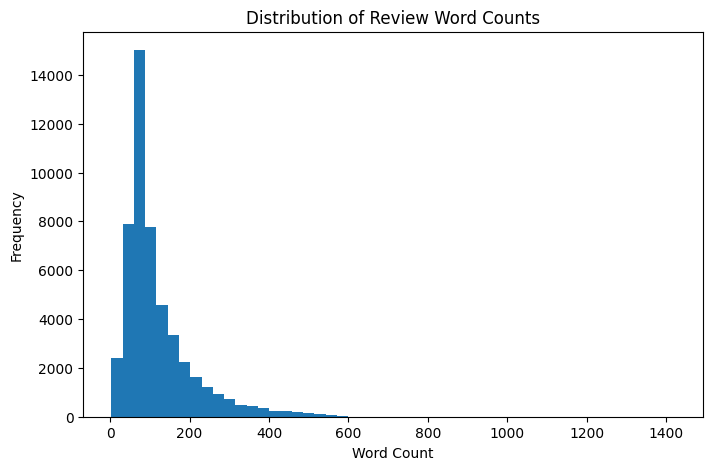

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(df["word_count"], bins=50)
plt.title("Distribution of Review Word Counts")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

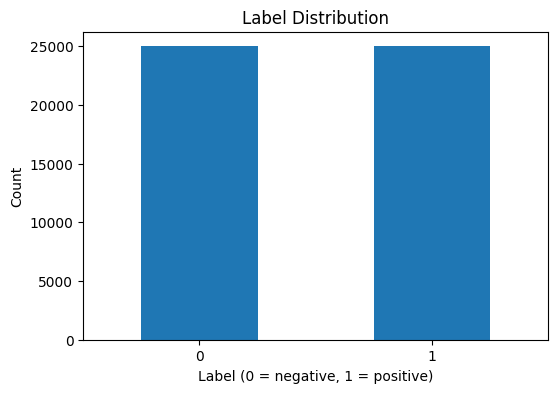

In [19]:
plt.figure(figsize=(6, 4))
df[label_col].value_counts().sort_index().plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Label (0 = negative, 1 = positive)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## Data Examples

In [20]:
for i in range(3):
    print("=" * 100)
    print(f"Sample {i}")
    print("Label:", df.iloc[i][label_col])
    print("Text:", df.iloc[i][text_col][:600])

Sample 0
Label: 1
Text: one review mention watch oz episod hook right exactli happen first thing struck oz brutal unflinch scene violenc set right word go trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use word call oz nicknam given oswald maximum secur state penitentari focu mainli emerald citi experi section prison cell glass front face inward privaci high agenda em citi home mani aryan muslim gangsta latino christian italian irish scuffl death stare dodgi deal shadi agreement never far away would say main appeal show due fact goe show dare forget pretti pictur paint mainstream
Sample 1
Label: 1
Text: wonder littl product film techniqu unassum old time bbc fashion give comfort sometim discomfort sen realism entir piec actor extrem well chosen michael sheen got polari voic pat truli see seamless edit guid refer william diari entri well worth watch terrificli written perform piec master product one great master comedi life realism realli come home 